# Challenger: split, features, treino, corte e comparação (Steps 3 a 7)

Este notebook constrói o modelo desafiante (Challenger). Ele começa pela base preparada com as decisões da EDA (`eda.ipynb`) e segue os passos:
- split out-of-time em treino, validação e teste;
- features que dependem de outras linhas (calculadas só no treino);
- treino do LightGBM e da regressão logística (baseline);
- escolha do ponto de corte pelo lucro em validação;
- comparação com o champion no teste.

## Imports e setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
LEGIT_COLOR, FRAUD_COLOR = "#2a78d6", "#eb6834"

## Dados e base preparada

Essa etapa consiste em realizar as transformações linha a linha antes de realizar o split dos dados para evitar qualquer leakage dentro das amostras resultantes. Para tanto, foram implementadas as seguintes transformações que foram trabalhadas no EDA:
- hora do dia;
- `pais` (BR, AR, UY, US e OUTROS);
- `o` com o nulo como categoria;
- drop de `k`, `c`, `e`, `g` e `i`.

In [54]:
df = pd.read_csv('https://hr-projects-assets-prod.s3.amazonaws.com/3st1g8gm56o/ed953178414189325c980dc1a9214b97/data.csv')

PAISES_PRINCIPAIS = ["BR", "AR", "UY", "US"]
INCIDENTE_BC_INICIO, INCIDENTE_BC_FIM = "2020-03-09", "2020-03-14"  # fim exclusivo: até 13/03 23:59
CATEGORICAS = ["a", "n", "o", "p", "pais"]
COLUNAS_DROP = ["k", "c", "e", "g", "i"]

def preparar_base(df):
    base = df.copy()
    base["fecha"] = pd.to_datetime(base["fecha"])

    # Hora do dia: risco maior na madrugada
    base["hora"] = base["fecha"].dt.hour

    # País: 4 principais + OUTROS (demais países e nulos)
    base["pais"] = base["g"].where(base["g"].isin(PAISES_PRINCIPAIS), "OUTROS")

    # o: nulo vira categoria (grupo de menor risco)
    base["o"] = base["o"].fillna("nulo")

    # Categóricas no formato que o LightGBM usa nativamente
    for col in CATEGORICAS:
        base[col] = base[col].astype(str).astype("category")

    return base.drop(columns=COLUNAS_DROP)

base = preparar_base(df)
base.shape

(150000, 17)

## Train/Test/Val - Split out-of-time

O split baseado em data foi realizado considerando o comportamento do modelo de fraude em ambiente produtivo. Ao utilizar amostras out-of-time garantimos que o modelo tem as transações simuladas no tempo adequado. 

| Conjunto | Período | Uso |
|---|---|---|
| **treino** | 08/03 a 05/04 | ajustar o modelo e todas as transformações que dependem de outras linhas |
| **validação** | 06/04 a 12/04 | early stopping, comparação entre modelos e escolha do ponto de corte |
| **teste** | 13/04 a 21/04 | usado **uma única vez**, no fim, para a comparação com o champion |

Os cortes caem em domingos (05/04 e 12/04), então cada semana fica inteira em um único conjunto.

In [55]:
VALIDACAO_INICIO = "2020-04-06"
TESTE_INICIO = "2020-04-13"

df_treino = base[base["fecha"] < VALIDACAO_INICIO]
df_val = base[(base["fecha"] >= VALIDACAO_INICIO) & (base["fecha"] < TESTE_INICIO)]
df_teste = base[base["fecha"] >= TESTE_INICIO]

# Conferência: nenhuma transação perdida ou repetida
assert len(df_treino) + len(df_val) + len(df_teste) == len(base)

In [56]:
splits = {"treino": df_treino, "validação": df_val, "teste": df_teste}

resumo_split = pd.DataFrame({
    nome: {
        "início": dados["fecha"].min().date(),
        "fim": dados["fecha"].max().date(),
        "dias": dados["fecha"].dt.date.nunique(),
        "transações": len(dados),
        "% das transações": len(dados) / len(base) * 100,
        "fraudes": dados["fraude"].sum(),
        "taxa de fraude %": dados["fraude"].mean() * 100,
        "monto total": dados["monto"].sum(),
        "score médio (champion)": dados["score"].mean(),
    }
    for nome, dados in splits.items()
}).T

# As colunas numéricas ficam como texto por causa das datas: converte para poder arredondar
colunas_numericas = resumo_split.columns.drop(["início", "fim"])
resumo_split[colunas_numericas] = resumo_split[colunas_numericas].astype(float).round(2)
resumo_split

,início,fim,dias,transações,% das transações,fraudes,taxa de fraude %,monto total,score médio (champion)
treino,2020-03-08,2020-04-05,29.0,90063.0,60.04,4607.0,5.12,4055638.11,50.26
validação,2020-04-06,2020-04-12,7.0,24443.0,16.30,1322.0,5.41,977182.94,44.93
teste,2020-04-13,2020-04-21,9.0,35494.0,23.66,1571.0,4.43,1495649.07,44.66


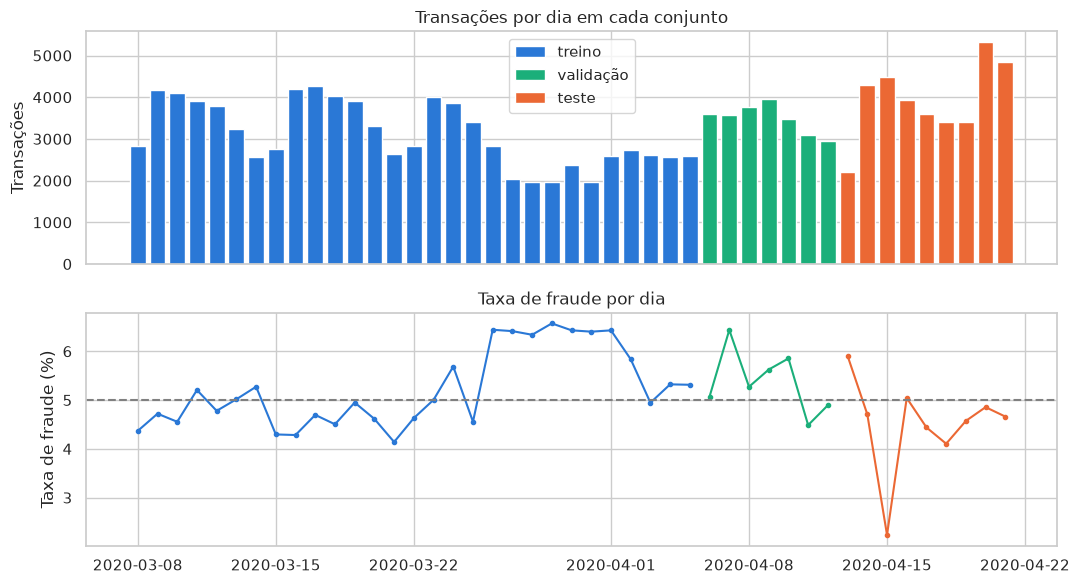

In [57]:
cores_split = {"treino": LEGIT_COLOR, "validação": "#1baf7a", "teste": FRAUD_COLOR}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for nome, dados in splits.items():
    diario = dados.groupby(dados["fecha"].dt.floor("D"))["fraude"].agg(transacoes="size", taxa="mean")
    ax1.bar(diario.index, diario["transacoes"], color=cores_split[nome], label=nome)
    ax2.plot(diario.index, diario["taxa"] * 100, color=cores_split[nome], marker="o", markersize=3)

ax1.set(title="Transações por dia em cada conjunto", ylabel="Transações")
ax1.legend()
ax2.axhline(base["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral
ax2.set(title="Taxa de fraude por dia", ylabel="Taxa de fraude (%)")
plt.tight_layout()
plt.show()

- **Tamanho:** O dataset de Treino fica com ~60% das transações (29 dias), validação com ~16% (7 dias) e teste com ~24% (9 dias). Essa divisão foi pensada de modo que todos tenham um número mínimo superior a 1.300 fraudes que é o suficiente para medir as métricas com estabilidade.
- **Taxa de fraude:** 5,1% em treino, 5,4% em validação e **4,4% em teste**. 
  - A queda na taxa de fraude em teste pode acontecer devido a maturidade da target de modo que as fraudes mais recentes podem ainda não ter sido contestadas no momento de extração dos dados.
- **Problema nas datas de `b`/`c`** (09 a 13/03): Apesar da grande taxa de nulos no período, a taxa de fraude que é apresentada é baixa se relativa a taxa de fraude total, dito isso manteve-se a `b`.

### Features Engineering (treino)

Algumas features dependem de outras transações para serem calculadas e caso fossem calculadas na base inteira o modelo usaria a informação dos conjuntos de validação e de teste, e a avaliação de performance do modelo ficaria enviesada. Por isso elas são ajustadas com base no conjunto de dados de treinamento e depois aplicadas seguindo a formatação definida nos três conjuntos.

Um exemplo disso é a frequência da categoria `j`. `j` tem 8.324 categorias, então em vez de usá-la diretamente usamos quantas transações do treino pertencem àquela categoria.

In [58]:
# Frequência de cada categoria de j, contada só no treino
freq_j = df_treino["j"].value_counts()

def adicionar_features(dados):
    dados = dados.copy()
    # Categoria nunca vista no treino recebe frequência 0
    dados["j_freq"] = dados["j"].map(freq_j).fillna(0)
    return dados

df_treino = adicionar_features(df_treino)
df_val = adicionar_features(df_val)
df_teste = adicionar_features(df_teste)

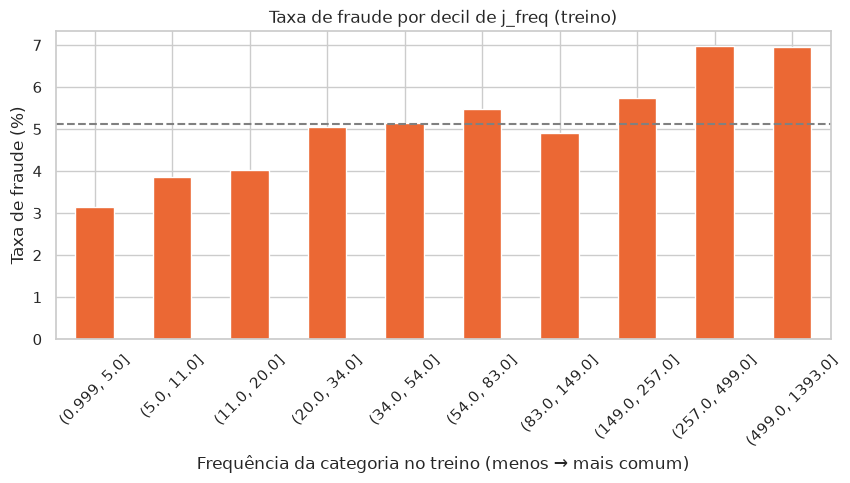

,KS de j_freq,% categoria nova (j_freq = 0),taxa de fraude nas categorias novas %
treino,0.100,0.000,NaN
validação,0.095,2.307,4.255
teste,0.094,2.474,3.986


In [59]:
from scipy.stats import ks_2samp

# Taxa de fraude por decil de j_freq, no treino
taxa_decil = df_treino.groupby(pd.qcut(df_treino["j_freq"], 10, duplicates="drop"), observed=True)["fraude"].mean() * 100
ax = taxa_decil.plot(kind="bar", color=FRAUD_COLOR, figsize=(10, 4))
ax.axhline(df_treino["fraude"].mean() * 100, color="gray", linestyle="--")  # média do treino
ax.set(title="Taxa de fraude por decil de j_freq (treino)", xlabel="Frequência da categoria no treino (menos → mais comum)",
       ylabel="Taxa de fraude (%)")
plt.xticks(rotation=45)
plt.show()

# Estabilidade do sinal e categorias novas em cada conjunto
pd.DataFrame({
    nome: {
        "KS de j_freq": ks_2samp(dados.loc[dados["fraude"] == 1, "j_freq"], dados.loc[dados["fraude"] == 0, "j_freq"]).statistic,
        "% categoria nova (j_freq = 0)": (dados["j_freq"] == 0).mean() * 100,
        "taxa de fraude nas categorias novas %": dados.loc[dados["j_freq"] == 0, "fraude"].mean() * 100,
    }
    for nome, dados in {"treino": df_treino, "validação": df_val, "teste": df_teste}.items()
}).T.round(3)

- Olhamos que as categorias dos últimos dois decis (as mais frequentes) são as que apresentam mais fraude saindo de 3,1% nas categorias menos frequentes para 7,0% nas mais comuns.
- Só 2,3% a 2,5% das transações dos dados de validação e dos de teste têm uma categoria que não aparece no treino. Elas recebem frequência 0, e a taxa de fraude delas é normal (~4%), então esse tratamento não distorce o resultado da análise.

### Considerações
- Não usamos a descrição contida na coluna `i` pois seria algo que podemos usar técnicas de PLN ou até modelos fundacionais, mas foge do escopo desse projeto
- Também não foram criadas features de velocidade (atreladas a informações como ip, tempo decorrido entre transações do mesmo usuário e etc) visto que não tem-se um identificador comum das transações declarado nas colunas
- Foram feitos alguns testes de combinações de features como valor transacionado relativo ao país, valor / `f` e valor / `l`, porém nenhuma trouxe ganho acima do ruído. Os testes estão detalhados na seção abaixo

In [60]:
FEATURES = ["a", "b", "d", "f", "h", "l", "m", "n", "o", "p", "monto", "hora", "pais", "j_freq"]
ALVO = "fraude"

X_treino, y_treino = df_treino[FEATURES], df_treino[ALVO]
X_val, y_val = df_val[FEATURES], df_val[ALVO]
X_teste, y_teste = df_teste[FEATURES], df_teste[ALVO]

# Conferências
assert len(X_treino) + len(X_val) + len(X_teste) == len(base)
assert not pd.concat([X_treino, X_val, X_teste])[CATEGORICAS].isnull().any().any()

print("Formato:", {"treino": X_treino.shape, "validação": X_val.shape, "teste": X_teste.shape})

# Nulos que sobram: só nas numéricas, tratados nativamente pelo LightGBM
pd.DataFrame({"treino": X_treino.isnull().sum(), "validação": X_val.isnull().sum(), "teste": X_teste.isnull().sum()}).query(
    "treino > 0 or validação > 0 or teste > 0")

Formato: {'treino': (90063, 14), 'validação': (24443, 14), 'teste': (35494, 14)}


,treino,validação,teste
b,12453,200,331
d,270,62,33
f,8,3,0
l,8,3,0
m,270,62,33


### Teste de combinações de features

Na análise exploratória a feature de `f` baixo e `monto` alto aparecem ligados a mais fraude independentemente. A hipótese é se a combinação dessas features (respectivamente seus comportamentos) resultaria em algum ganho para o modelo, ou se apenas a abstração interna do modelo já seria o suficiente para identificar tais padrões

Testamos três candidatas:
- `monto_rel_pais`: `monto` dividido pela média de `monto` do país no treino
- `monto_sobre_f` e `monto_sobre_l`: `monto` dividido por `f + 1` e por `l + 1`. 

In [61]:
# Candidatas, todas calculadas com informação do treino
media_monto_pais = df_treino.groupby("pais", observed=True)["monto"].mean()

def adicionar_combinacoes(dados):
    dados = dados.copy()
    dados["monto_rel_pais"] = dados["monto"] / dados["pais"].map(media_monto_pais).astype(float)
    dados["monto_sobre_f"] = dados["monto"] / (dados["f"].fillna(0) + 1)
    dados["monto_sobre_l"] = dados["monto"] / (dados["l"].fillna(0) + 1)
    return dados

CANDIDATAS = ["monto_rel_pais", "monto_sobre_f", "monto_sobre_l"]
treino_comb = adicionar_combinacoes(df_treino)
val_comb = adicionar_combinacoes(df_val)

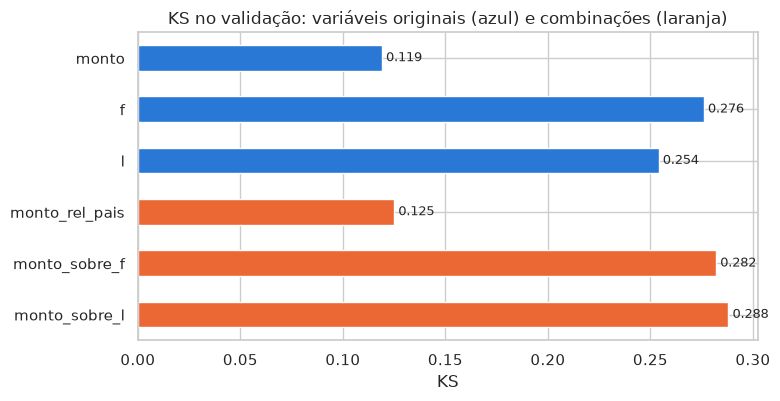

In [62]:
def ks(dados, col):
    x = dados[[col, "fraude"]].dropna()
    return ks_2samp(x.loc[x["fraude"] == 1, col], x.loc[x["fraude"] == 0, col]).statistic

# KS na validação: cada candidata ao lado das variáveis de origem
comparacao_ks = pd.Series({col: ks(val_comb, col) for col in ["monto", "f", "l"] + CANDIDATAS}).round(3)

cores = [FRAUD_COLOR if col in CANDIDATAS else LEGIT_COLOR for col in comparacao_ks.index]
ax = comparacao_ks.plot(kind="barh", color=cores, figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)
ax.set(title="KS na validação: variáveis originais (azul) e combinações (laranja)", xlabel="KS")
ax.invert_yaxis()
plt.show()

Se olharmos ao gráfico vemos que o comparativo aponta um resultado interessante, as features combinadas não ganham praticamente nada em performance comparadas com as features em seu estado primordial. Logo, pode-se inferir que para as que foram selecionadas podemos seguir sem alteração. Isso pode ser um caso diferente para outras combinações de features e até criação de features de velocidade, porém como foi referido, está fora do escopo e do tempo hábil deste projeto.

### Features finais

| Feature | Tipo | Por que entra |
|---|---|---|
| `f`, `l`, `m` | numérica | Fraude nos menores valores |
| `d` | numérica | KS moderado de 0,17 |
| `h` | numérica | sinal fraco (KS 0,09), mas com tendência consistente |
| `b` | numérica | sinal concentrado nos maiores valores (~9% de fraude no último decil) |
| `monto` | numérica | fraude aparece concentrada nos valores altos |
| `o` | categórica | KS 0,45: `N` concentra metade das fraudes; nulo = grupo de menor risco |
| `n` | categórica | `n = 0` tem 16,1% de fraude |
| `p` | categórica | `p = N` tem 7,6% de fraude vs 2,9% em `Y` |
| `a` | categórica | níveis 1 a 3 com 7,8% a 9,4% de fraude vs 4,5% no nível 4 |
| `pais` | categórica | BR 5,5%, AR 3,7%, UY 1,0%, US 3,1% |
| `hora` | numérica | madrugada (0h a 5h) com **11,3%** de fraude |
| `j_freq` | numérica | categorias mais comuns têm mais fraude (KS 0,10, estável) |

Total de 14 features

## Treino do Challenger

Foram treinados dois modelos com as 14 features resultantes da análise do EDA + Feature engineering:
- uma **regressão logística**, modelo mais simples e com menor complexidade que serve de baseline.
- o **LightGBM**, que é o Challenger escolhido para comparar com o modelo vigente/champion (scores da tabela).

Os dois aprendem só com o dataset de treino. O conjunto de validação é usado para o early stopping do LightGBM e para comparar os modelos entre si e com o champion.

In [63]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

def metricas(y, prob):
    y, prob = np.asarray(y), np.asarray(prob)
    return {
        "ROC-AUC": roc_auc_score(y, prob),
        "PR-AUC": average_precision_score(y, prob),
        "KS": ks_2samp(prob[y == 1], prob[y == 0]).statistic,
    }

### Baseline: regressão logística

A regressão logística não aceita nulos nem categorias em texto, então ela recebe um pré-processamento próprio ajustado no momento treino:
- Para as variáveis numéricas é feito o preenchimento dos nulos com um imputer com a mediana do treino e adicionou-se uma coluna de flag mostrando onde havia o nulo para não perder seu sinal
- As variáveis numéricas são padronizadas usando um StandardScaler jogando a média para 0 e std para 1
- Para as features categóricas é usado o one-hot encoding 

In [64]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

NUMERICAS = [c for c in FEATURES if c not in CATEGORICAS]

pre_processamento = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), NUMERICAS),
    (OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
)
modelo_lr = make_pipeline(pre_processamento, LogisticRegression(max_iter=2000))
modelo_lr.fit(X_treino, y_treino)

prob_val_lr = modelo_lr.predict_proba(X_val)[:, 1]

### Challenger: LightGBM

O LightGBM usa as features sem qualquer transformação, sendo que internamente é feito o tratamento das categóricas como tipo `category`, as numéricas como tipo `numeric` e os nulos são tratados pela própria lógica interna do modelo.

A princípio não foi feita uma busca de hiperparâmetros, assim atendo-se ao padrão, com uma taxa de aprendizado de 0,05 e early stopping em que o modelo avalia a cada iteração se houve melhora nos resultados sobre o conjunto de validação, e caso não, ele para depois de 100 árvores sem ganho.

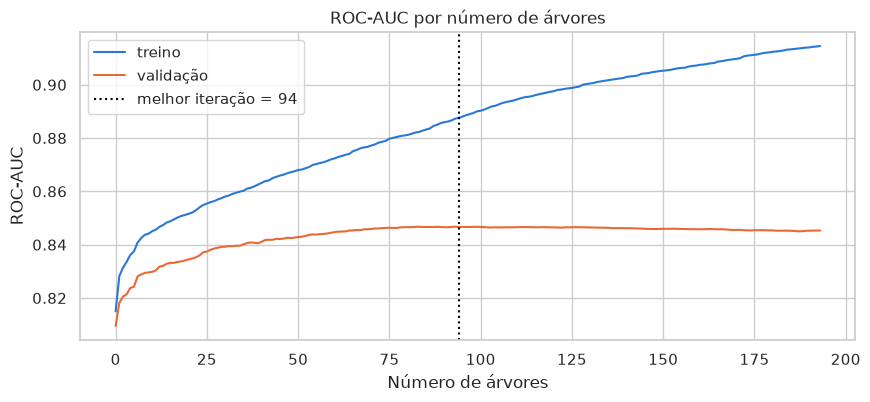

In [65]:
import lightgbm as lgb

modelo_lgbm = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, random_state=42, verbose=-1)
modelo_lgbm.fit(
    X_treino, y_treino,
    eval_set=[(X_treino, y_treino), (X_val, y_val)],
    eval_names=["treino", "validação"],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
prob_val_lgbm = modelo_lgbm.predict_proba(X_val)[:, 1]

auc = pd.DataFrame({nome: res["auc"] for nome, res in modelo_lgbm.evals_result_.items()})
ax = auc.plot(color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(10, 4))
ax.axvline(modelo_lgbm.best_iteration_, color="black", linestyle=":", label=f"melhor iteração = {modelo_lgbm.best_iteration_}")
ax.set(title="ROC-AUC por número de árvores", xlabel="Número de árvores", ylabel="ROC-AUC")
ax.legend()
plt.show()

### Comparação na validação

In [66]:
comparacao_val = pd.DataFrame({
    "champion (score)": metricas(y_val, df_val["score"]),
    "Regressão logística": metricas(y_val, prob_val_lr),
    "LightGBM": metricas(y_val, prob_val_lgbm),
}).T
comparacao_val.round(3)

,ROC-AUC,PR-AUC,KS
champion (score),0.725,0.247,0.445
Regressão logística,0.833,0.304,0.522
LightGBM,0.847,0.383,0.541


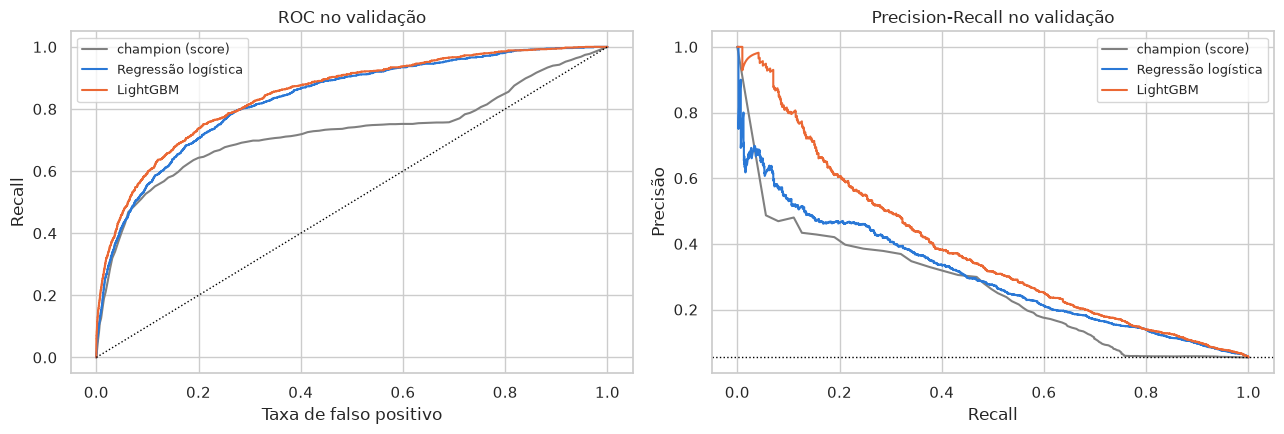

In [67]:
modelos_val = {"champion (score)": (df_val["score"], "gray"), "Regressão logística": (prob_val_lr, LEGIT_COLOR),
               "LightGBM": (prob_val_lgbm, FRAUD_COLOR)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for nome, (prob, cor) in modelos_val.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    precisao, recall, _ = precision_recall_curve(y_val, prob)
    ax1.plot(fpr, tpr, color=cor, label=nome)
    ax2.plot(recall, precisao, color=cor, label=nome)

ax1.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
ax1.set(title="ROC na validação", xlabel="Taxa de falso positivo", ylabel="Recall")
ax2.axhline(y_val.mean(), color="black", linestyle=":", linewidth=1)  # modelo aleatório
ax2.set(title="Precision-Recall na validação", xlabel="Recall", ylabel="Precisão")
ax1.legend(fontsize=9)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

Ambos os novos modelos superam o champion em validação em todas as métricas. O LightGBM fica à frente da regressão logística, mas a distância muda conforme a métrica: na ROC-AUC e no KS a diferença é pequena (cerca de 0,01 a 0,02), enquanto na PR-AUC ela é bem maior (0,38 contra 0,30). A PR-AUC olha só para a classe de fraude, e é nela que o LightGBM se destaca: ele acerta mais quando aponta uma transação como fraude, principalmente no topo do ranking. É lá que fica o ponto de corte.

A curva ROC mostra outra diferença. O champion tem um trecho quase plano no meio, com fraudes que ele classifica com score baixo. Os modelos novos não têm esse trecho: eles conseguem ordenar parte dessas fraudes.

A regressão logística ter ido tão bem também diz algo: boa parte do sinal está em poucas variáveis fortes, com destaque para `o`. Mesmo assim, o LightGBM entrega mais precisão sem nenhum trabalho extra de feature engineering, e por isso segue como Challenger.

Esses números são da aplicação dos modelos no conjunto de validação, que também foi usado no early stopping, então tendem a ser um pouco otimistas. A comparação final é realizada observando o conjunto de teste.

### Importância das features

O cálculo de importância das features mede o impacto de cada feature na redução do erro do modelo

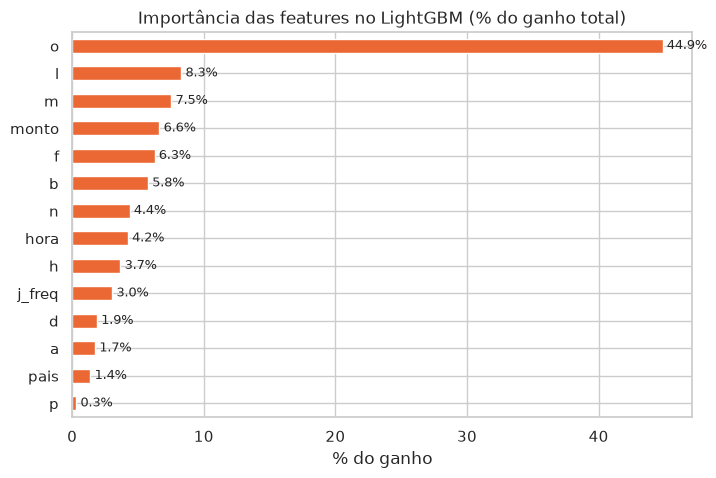

In [68]:
feat_importance = pd.Series(modelo_lgbm.booster_.feature_importance(importance_type="gain"), index=FEATURES)
feat_importance = (feat_importance / feat_importance.sum() * 100).sort_values()

ax = feat_importance.plot(kind="barh", color=FRAUD_COLOR, figsize=(8, 5))
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
ax.set(title="Importância das features no LightGBM (% do ganho total)", xlabel="% do ganho")
plt.show()

**Leitura**

O modelo confirma a leitura da EDA. `o` responde por quase metade do ganho, o que bate com o KS de 0,45 que ela tem sozinha. Depois vêm `l`, `m`, `f` e `monto`, as numéricas que já tinham a melhor separação.

A feature `p` possui uma relevância contrária à análise do EDA, ficando em última posição como mais baixa importância. Provavelmente porque a informação dela se sobrepõe à de `o` e `n`.

### Teste: o modelo sem `o`

Pelo EDA foi-se levantado o teste sem o uso da feature `o` a fim de verificar seu peso no modelo. Para isso foi treinado o mesmo modelo (LightGBM) e avaliado o resultado

In [69]:
features_sem_o = [c for c in FEATURES if c != "o"]

modelo_sem_o = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, random_state=42, verbose=-1)
modelo_sem_o.fit(X_treino[features_sem_o], y_treino, eval_set=[(X_val[features_sem_o], y_val)], eval_metric="auc",
                 callbacks=[lgb.early_stopping(100, verbose=False)])

pd.DataFrame({
    "LightGBM com o": metricas(y_val, prob_val_lgbm),
    "LightGBM sem o": metricas(y_val, modelo_sem_o.predict_proba(X_val[features_sem_o])[:, 1]),
    "champion (score)": metricas(y_val, df_val["score"]),
}).T.round(3)

,ROC-AUC,PR-AUC,KS
LightGBM com o,0.847,0.383,0.541
LightGBM sem o,0.766,0.271,0.395
champion (score),0.725,0.247,0.445


Sem a presença da feature `o`, o modelo perde boa parte do desempenho, sua ROC-AUC cai de 0,85 para 0,77 e o KS de 0,54 para 0,40, abaixo do próprio champion (0,45). Dito isso, a decisão de manter `o`, mesmo com a altíssima taxa de nulos de 72,6% é resguardada pelo fato de exercer um dos maiores pesos em que seus nulos não são ruído para o modelo, mas sim informação discriminatória.

## Aplicação da lógica de negócio

A regra de negócio consiste em que uma transação legítima aprovada rende 10% do valor total (`monto`), uma fraude aprovada custa 100% desse valor e uma transação recusada não rende nem custa nada. O modelo recusa quando a probabilidade de fraude é maior ou igual ao valor de corte. Esse valor de corte é escolhido com os resultados da **validação** do modelo, testando todos os valores e ficando com o que dá o maior retorno financeiro, sendo armazenado e aplicado no teste

De uma forma prática, para uma transação com probabilidade de fraude `p`, aprovar vale a pena quando o ganho esperado supera a perda esperada:

`(1 − p) · 0,10 · monto > p · monto`  →  `p < 0,10 / 1,10 = 1/11 ≈ 0,091`

O `monto` aparece dos dois lados e se cancela: o corte ideal não depende do valor da transação. Se as probabilidades do modelo forem bem calibradas, o melhor corte encontrado nos dados deve ficar perto de 0,091.

In [70]:
def lucro(dados, corte, col_score):
    """Lucro da regra de negócio: recusa quando o score (ou a probabilidade) >= corte."""
    aprovada = dados[col_score] < corte
    ganho = 0.10 * dados.loc[aprovada & (dados["fraude"] == 0), "monto"].sum()
    perda = dados.loc[aprovada & (dados["fraude"] == 1), "monto"].sum()
    return ganho - perda

def resumo_corte(dados, corte, col_score):
    recusada = dados[col_score] >= corte
    fraude = dados["fraude"] == 1
    return {
        "corte": corte,
        "lucro": lucro(dados, corte, col_score),
        "taxa_recusa_%": recusada.mean() * 100,
        "recall_%": (recusada & fraude).sum() / fraude.sum() * 100,      # fraudes recusadas / total de fraudes
        "precisao_%": (recusada & fraude).sum() / recusada.sum() * 100,  # fraudes entre as recusadas
    }

# Conferência à mão: corte 50 aprova as linhas 1 e 3 → 0,10 × 100 − 30 = −20
exemplo = pd.DataFrame({"score": [20, 90, 40], "monto": [100.0, 50.0, 30.0], "fraude": [0, 1, 1]})
assert lucro(exemplo, 50, "score") == -20

In [71]:
df_val = df_val.assign(prob_lgbm=prob_val_lgbm)

CORTES_PROB = np.round(np.arange(0, 1.0001, 0.005), 3)  # probabilidade do LightGBM
CORTES_SCORE = np.arange(0, 102)                        # score do champion (101 = aprovar tudo)

curva_lgbm = pd.Series({c: lucro(df_val, c, "prob_lgbm") for c in CORTES_PROB})
curva_champion = pd.Series({c: lucro(df_val, c, "score") for c in CORTES_SCORE})

# Pontos de corte congelados: não mudam mais daqui em diante
CORTE_LGBM = curva_lgbm.idxmax()
CORTE_CHAMPION = curva_champion.idxmax()
CORTE_TEORICO = 1 / 11
lucro_aprovar_tudo_val = lucro(df_val, np.inf, "score")

print(f"LightGBM: recusar quando prob >= {CORTE_LGBM} | champion: recusar quando score >= {CORTE_CHAMPION}")

LightGBM: recusar quando prob >= 0.075 | champion: recusar quando score >= 74


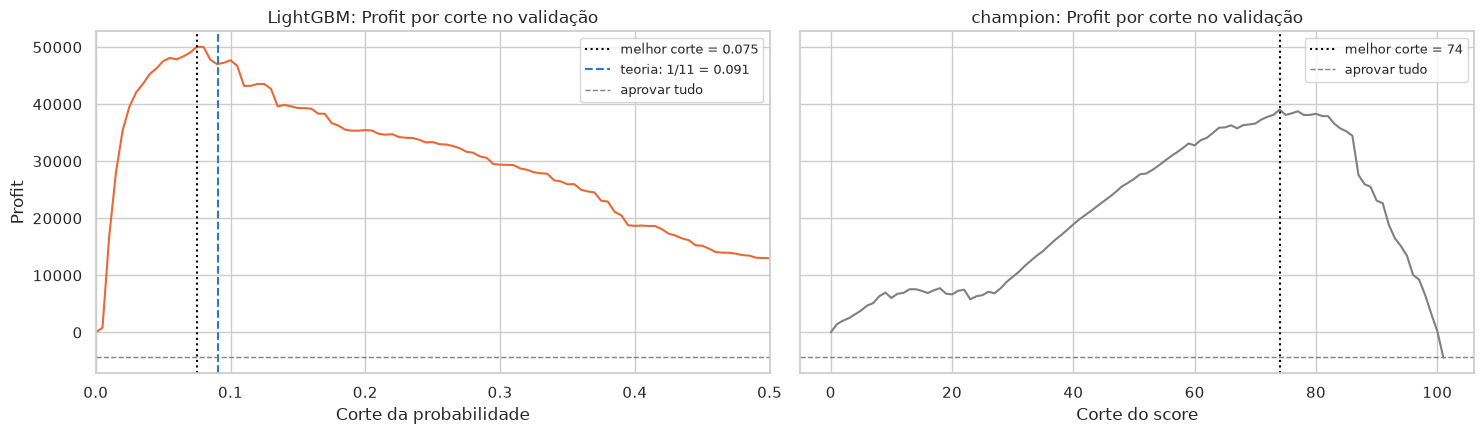

,corte,lucro,taxa_recusa_%,recall_%,precisao_%
champion (score),74.000,39046.980,19.376,61.271,17.103
LightGBM,0.075,50043.586,16.913,65.809,21.045
LightGBM no corte teórico (1/11),0.091,47090.242,13.415,60.741,24.489


In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)

ax1.plot(curva_lgbm.index, curva_lgbm.values, color=FRAUD_COLOR)
ax1.axvline(CORTE_LGBM, color="black", linestyle=":", label=f"melhor corte = {CORTE_LGBM}")
ax1.axvline(CORTE_TEORICO, color=LEGIT_COLOR, linestyle="--", label=f"teoria: 1/11 = {CORTE_TEORICO:.3f}")
ax1.set(title="LightGBM: lucro por corte na validação", xlabel="Corte da probabilidade", ylabel="Lucro", xlim=(0, 0.5))

ax2.plot(curva_champion.index, curva_champion.values, color="gray")
ax2.axvline(CORTE_CHAMPION, color="black", linestyle=":", label=f"melhor corte = {CORTE_CHAMPION}")
ax2.set(title="Champion: lucro por corte na validação", xlabel="Corte do score")

for ax in (ax1, ax2):
    ax.axhline(lucro_aprovar_tudo_val, color="gray", linestyle="--", linewidth=1, label="aprovar tudo")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "champion (score)": resumo_corte(df_val, CORTE_CHAMPION, "score"),
    "LightGBM": resumo_corte(df_val, CORTE_LGBM, "prob_lgbm"),
    "LightGBM no corte teórico (1/11)": resumo_corte(df_val, CORTE_TEORICO, "prob_lgbm"),
}).T.round(3)

**Leitura**

O melhor corte do LightGBM no conjunto de validação é **0,075**, ao lado do valor teórico de 0,091. A curva é quase plana entre 0,05 e 0,10, então pequenas mudanças no corte não alteram muito o resultado. Isso é bom para produção, porque o resultado não depende de acertar o corte com precisão.

No melhor corte, o LightGBM gera 50,0 mil de lucro em validação, contra 39,0 mil do champion no melhor corte dele (score ≥ 74). Ele faz isso **recusando menos** (16,9% contra 19,4% das transações) e barrando mais fraude (recall de 65,8% contra 61,3%). A precisão também é maior: 21% das transações recusadas pelo LightGBM são fraude, contra 17% no champion.

### Por que o corte ficou perto de 1/11: calibração

O corte teórico só vale se a probabilidade do modelo for uma probabilidade de verdade: entre as transações com probabilidade de 8%, cerca de 8% devem ser fraude. O gráfico abaixo divide o conjunto de validação em 10 faixas de probabilidade e compara a média prevista com a taxa de fraude real de cada faixa.

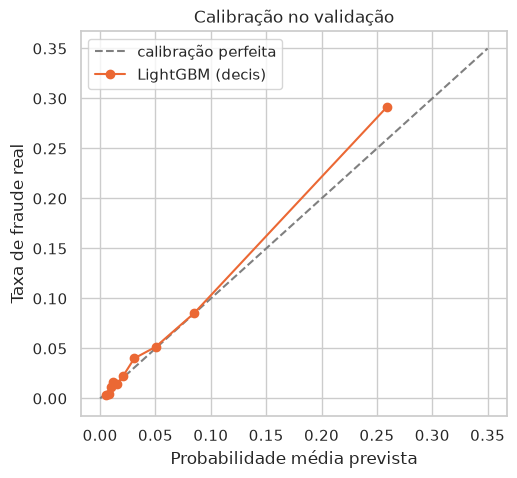

Probabilidade média prevista: 4.96% | taxa real: 5.41%
Brier score: 0.0412


In [73]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

real, previsto = calibration_curve(y_val, prob_val_lgbm, n_bins=10, strategy="quantile")

ax = plt.figure(figsize=(5.5, 5)).gca()
ax.plot([0, 0.35], [0, 0.35], color="gray", linestyle="--", label="calibração perfeita")
ax.plot(previsto, real, marker="o", color=FRAUD_COLOR, label="LightGBM (decis)")
ax.set(title="Calibração na validação", xlabel="Probabilidade média prevista", ylabel="Taxa de fraude real")
ax.legend()
plt.show()

print(f"Probabilidade média prevista: {prob_val_lgbm.mean():.2%} | taxa real: {y_val.mean():.2%}")
print(f"Brier score: {brier_score_loss(y_val, prob_val_lgbm):.4f}")

Os pontos ficam colados na diagonal até perto de 0,10, que é a região onde o corte é decidido. Só no decil mais alto o modelo subestima um pouco (prevê 26% e acontece 29%), o que não afeta o corte. A média prevista (4,96%) também fica perto da taxa real (5,41%).

O LightGBM foi treinado sem reamostragem nem pesos de classe, e por isso as probabilidades já saem calibradas. Esse é um dos motivos de não termos usado SMOTE: ele distorceria as probabilidades, e o corte de 1/11 deixaria de valer.

## Execução no conjunto de teste

O teste (13/04 a 21/04) é usado agora pela primeira e única vez. Os dois modelos usam os cortes congelados na etapa anterior, e nada é reajustado olhando para esses dados.

Além do champion e do LightGBM, a comparação de lucro inclui duas referências:
- **aprovar tudo**, que é o resultado sem nenhum modelo;
- **modelo perfeito**, que recusa todas as fraudes e aprova todas as legítimas. É o teto do lucro possível nesse período.

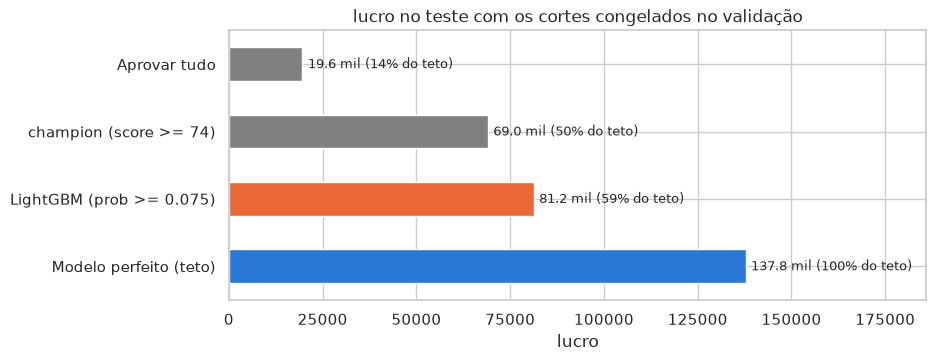

In [75]:
df_teste = df_teste.assign(prob_lgbm=modelo_lgbm.predict_proba(X_teste)[:, 1])

teto_teste = 0.10 * df_teste.loc[df_teste["fraude"] == 0, "monto"].sum()  # recusa todas as fraudes e aprova todas as legítimas
lucros_test = pd.Series({
    "Aprovar tudo": lucro(df_teste, np.inf, "score"),
    f"champion (score >= {CORTE_CHAMPION})": lucro(df_teste, CORTE_CHAMPION, "score"),
    f"LightGBM (prob >= {CORTE_LGBM})": lucro(df_teste, CORTE_LGBM, "prob_lgbm"),
    "Modelo perfeito (teto)": teto_teste,
})

ax = lucros_test.plot(kind="barh", color=["gray", "gray", FRAUD_COLOR, LEGIT_COLOR], figsize=(9, 3.5))
ax.bar_label(ax.containers[0], labels=[f"{v / 1000:.1f} mil ({v / teto_teste:.0%} do teto)" for v in lucros_test], padding=4, fontsize=9)
ax.set(title="Lucro no teste com os cortes congelados na validação", xlabel="Lucro", xlim=(0, teto_teste * 1.35))
ax.invert_yaxis()
plt.show()

No teste, o LightGBM gera **81,2 mil** de lucro, contra **69,0 mil** do champion: um ganho de 12,2 mil (+18%). Em relação ao teto, o LightGBM captura 59% do lucro possível e o champion, 50%. Aprovar tudo ficaria em 19,6 mil (14% do teto).

In [76]:
prob_test_lr = modelo_lr.predict_proba(X_teste)[:, 1]

ranking_test = pd.DataFrame({
    "champion (score)": metricas(y_teste, df_teste["score"]),
    "Regressão logística": metricas(y_teste, prob_test_lr),
    "LightGBM": metricas(y_teste, df_teste["prob_lgbm"])
}).T
decisao_test = pd.DataFrame({
    "champion (score)": resumo_corte(df_teste, CORTE_CHAMPION, "score"),
    "LightGBM": resumo_corte(df_teste, CORTE_LGBM, "prob_lgbm"),
}).T.drop(columns="corte")

# Métricas de decisão só para os dois modelos que tiveram corte escolhido na validação
ranking_test.join(decisao_test).round(3)

,ROC-AUC,PR-AUC,KS,lucro,taxa_recusa_%,recall_%,precisao_%
champion (score),0.733,0.229,0.463,69022.810,18.798,62.635,14.748
Regressão logística,0.832,0.272,0.512,NaN,NaN,NaN,NaN
LightGBM,0.845,0.339,0.534,81237.201,16.701,65.882,17.460


O LightGBM supera o champion em todas as métricas do teste:
- na separação, a ROC-AUC sobe de 0,733 para 0,845, a PR-AUC de 0,229 para 0,339 e o KS de 0,463 para 0,534;
- na decisão, ele recusa menos transações (16,7% contra 18,8%), barra um pouco mais de fraude (recall de 65,9% contra 62,6%) e erra menos ao recusar (precisão de 17,5% contra 14,7%). Na prática, menos clientes legítimos são barrados para o mesmo nível de proteção.

### O ganho se repete dia a dia?

Um ganho no total do teste pode vir de um ou dois dias bons. Para checar se ele é consistente, calculamos o lucro dos dois modelos em cada dia do teste, com os mesmos cortes congelados, e comparamos.

In [ ]:
lucro_dia = pd.DataFrame({
    "LightGBM": df_teste.groupby(df_teste["fecha"].dt.date).apply(lambda d: lucro(d, CORTE_LGBM, "prob_lgbm")),
    "champion": df_teste.groupby(df_teste["fecha"].dt.date).apply(lambda d: lucro(d, CORTE_CHAMPION, "score")),
})
lucro_dia["ganho do LightGBM"] = lucro_dia["LightGBM"] - lucro_dia["champion"]

ax = lucro_dia["ganho do LightGBM"].plot(kind="bar", color=[FRAUD_COLOR if g > 0 else "gray" for g in lucro_dia["ganho do LightGBM"]],
                                          figsize=(10, 4))
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Ganho de lucro do LightGBM sobre o champion em cada dia do teste", xlabel="Dia", ylabel="Ganho de lucro")
plt.xticks(rotation=45)
plt.show()

print(f"O LightGBM teve lucro maior em {(lucro_dia['ganho do LightGBM'] > 0).sum()} de {len(lucro_dia)} dias")
lucro_dia.round(0)

O LightGBM teve lucro maior em **8 dos 9 dias** do teste. No único dia restante (15/04) os dois ficam praticamente empatados, com diferença de 4. Os ganhos diários vão de cerca de 100 a 2,9 mil, e somados dão os 12,2 mil do total.

Ou seja, o ganho não vem de um dia atípico: ele aparece de forma repetida ao longo do período. Essa checagem é mais simples que um teste estatístico formal, mas responde à mesma pergunta prática: se o modelo novo for colocado em produção, ele tende a render mais na maioria dos dias.

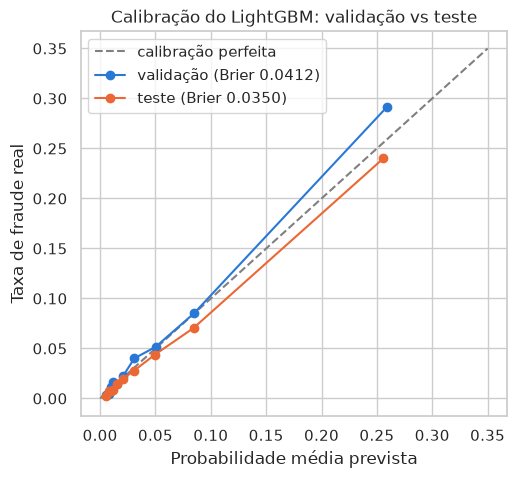

teste: probabilidade média prevista 4.92% | taxa real 4.43%


In [82]:
ax = plt.figure(figsize=(5.5, 5)).gca()
ax.plot([0, 0.35], [0, 0.35], color="gray", linestyle="--", label="calibração perfeita")
for nome, y, prob, cor in [("validação", y_val, prob_val_lgbm, LEGIT_COLOR), ("teste", y_teste, df_teste["prob_lgbm"], FRAUD_COLOR)]:
    real, previsto = calibration_curve(y, prob, n_bins=10, strategy="quantile")
    ax.plot(previsto, real, marker="o", color=cor, label=f"{nome} (Brier {brier_score_loss(y, prob):.4f})")
ax.set(title="Calibração do LightGBM: validação vs teste", xlabel="Probabilidade média prevista", ylabel="Taxa de fraude real")
ax.legend()
plt.show()

print(f"Teste: probabilidade média prevista {df_teste['prob_lgbm'].mean():.2%} | taxa real {y_teste.mean():.2%}")

No teste, o modelo superestima um pouco as probabilidades: a média prevista é 4,92% e a taxa real é 4,43%. A curva do teste fica abaixo da diagonal, principalmente no decil mais alto. Isso é coerente com a taxa de fraude mais baixa do teste, vista no split, e com a hipótese de maturidade do rótulo: parte das fraudes recentes pode ainda não ter sido confirmada. Mesmo assim, o desvio é pequeno e fica longe da região do corte.

In [83]:
teto_val = 0.10 * df_val.loc[df_val["fraude"] == 0, "monto"].sum()

pd.DataFrame({
    nome: {
        "dias": dados["fecha"].dt.date.nunique(),
        "lucro LightGBM": lucro(dados, CORTE_LGBM, "prob_lgbm"),
        "lucro champion": lucro(dados, CORTE_CHAMPION, "score"),
        "LightGBM % do teto": lucro(dados, CORTE_LGBM, "prob_lgbm") / teto * 100,
        "champion % do teto": lucro(dados, CORTE_CHAMPION, "score") / teto * 100,
        "KS LightGBM": metricas(dados["fraude"], dados["prob_lgbm"])["KS"],
        "taxa de fraude %": dados["fraude"].mean() * 100,
    }
    for nome, dados, teto in [("validação", df_val, teto_val), ("teste", df_teste, teto_teste)]
}).T.round(3)

,dias,lucro LightGBM,lucro champion,LightGBM % do teto,champion % do teto,KS LightGBM,taxa de fraude %
validação,7.0,50043.586,39046.98,56.587,44.153,0.541,5.409
teste,9.0,81237.201,69022.81,58.973,50.106,0.534,4.426


O conjunto de validação foi usado para o early stopping e para escolher o corte, então era de esperar que o desempenho caísse no teste. A queda quase não aparece: o KS vai de 0,541 para 0,534, e o lucro como % do teto até sobe (de 57% para 59%). O champion também sobe nessa medida (de 44% para 50%), o que sugere que o período de teste é um pouco mais fácil, possivelmente pela taxa de fraude menor. Em termos absolutos, os dois conjuntos têm durações diferentes (7 e 9 dias), por isso a comparação usa a % do teto.

## Conclusão
Como o novo modelo se compara ao atual: No conjunto de teste o LightGBM supera o champion em todas as métricas: ROC-AUC de 0,845 contra 0,733, PR-AUC de 0,339 contra 0,229 e KS de 0,534 contra 0,463. Observando a questão de valor de lucro, o novo modelo gera 81,2 mil de lucro contra 69,0 mil, sendo esse um ganho de 12,2 mil no total, que se repetiu em 8 dos 9 dias do teste. Além disso, o LightGBM faz isso recusando menos transações (16,7% contra 18,8%), ou seja, com menos atrito para clientes pagantes.

Ponto de corte que maximiza o lucro: Estabelece a recusa de uma transação quando a probabilidade resultante do modelo for maior ou igual a 0,075. Caso a taxa de fraude real em ambiente produtivo for menor ou maior que os 5% observados na amostra, o corte deve ser reajustado de acordo.